[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


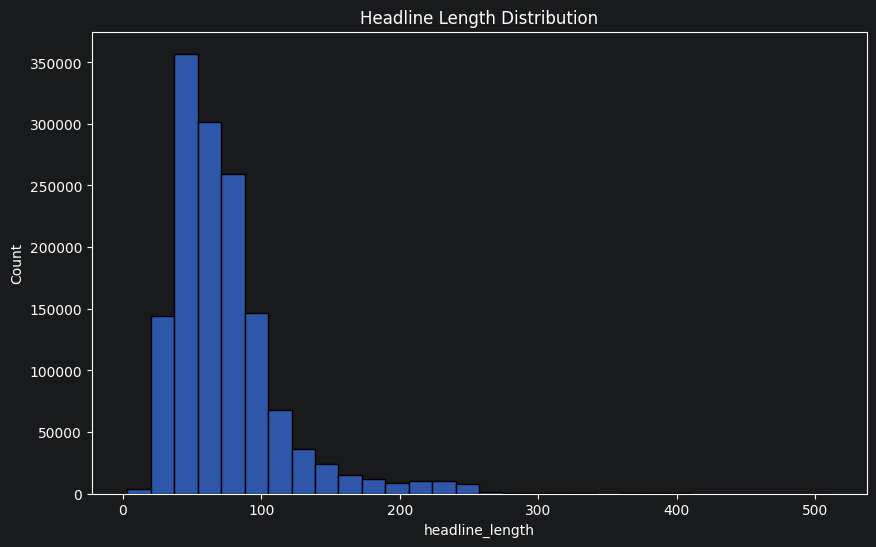

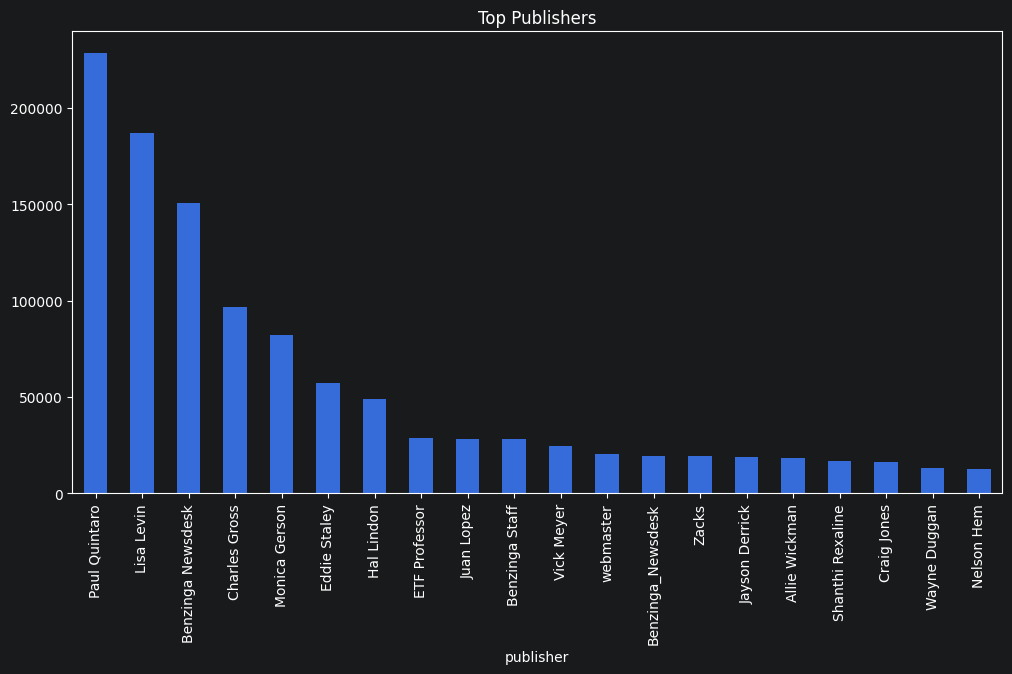

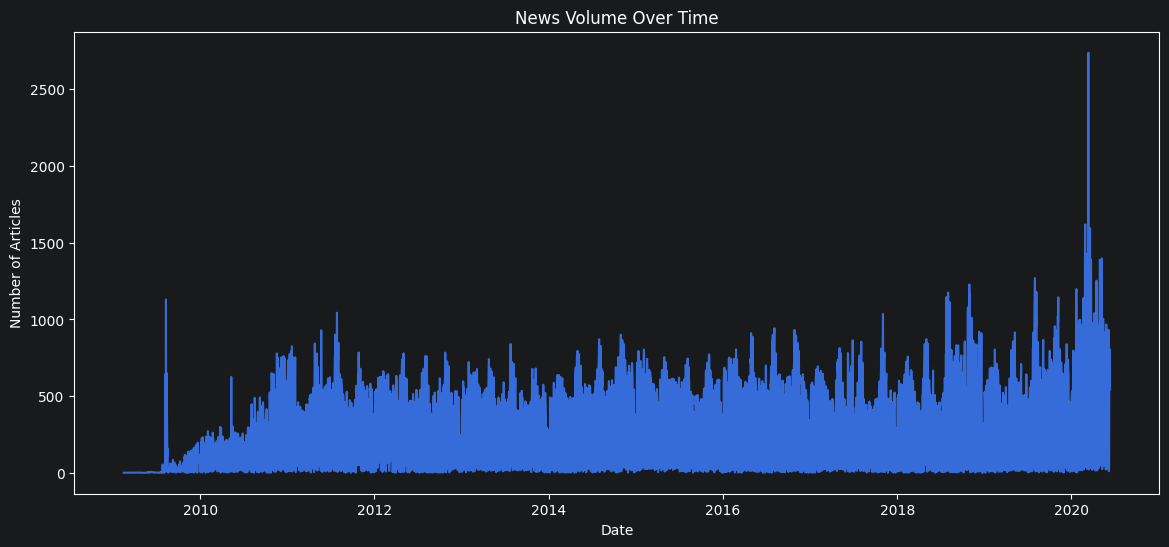

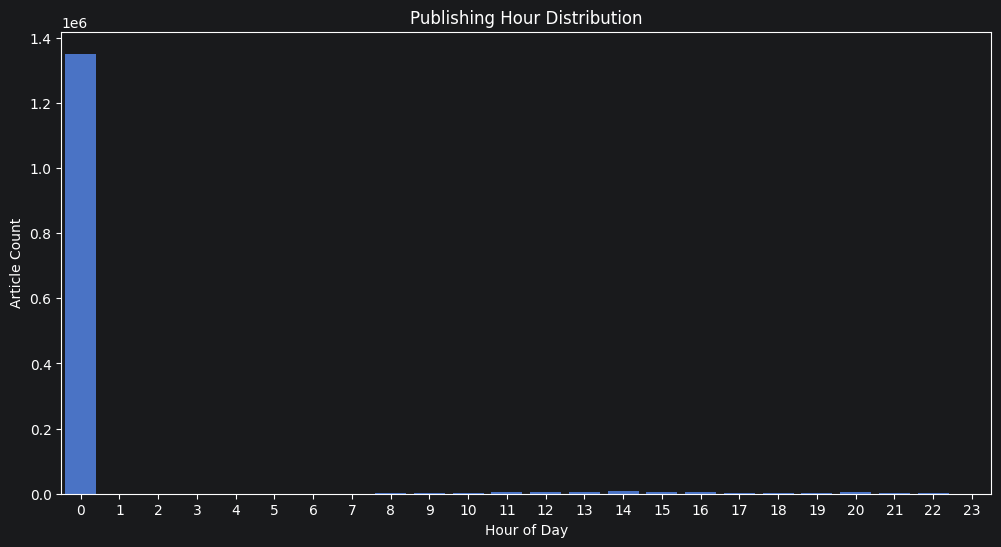

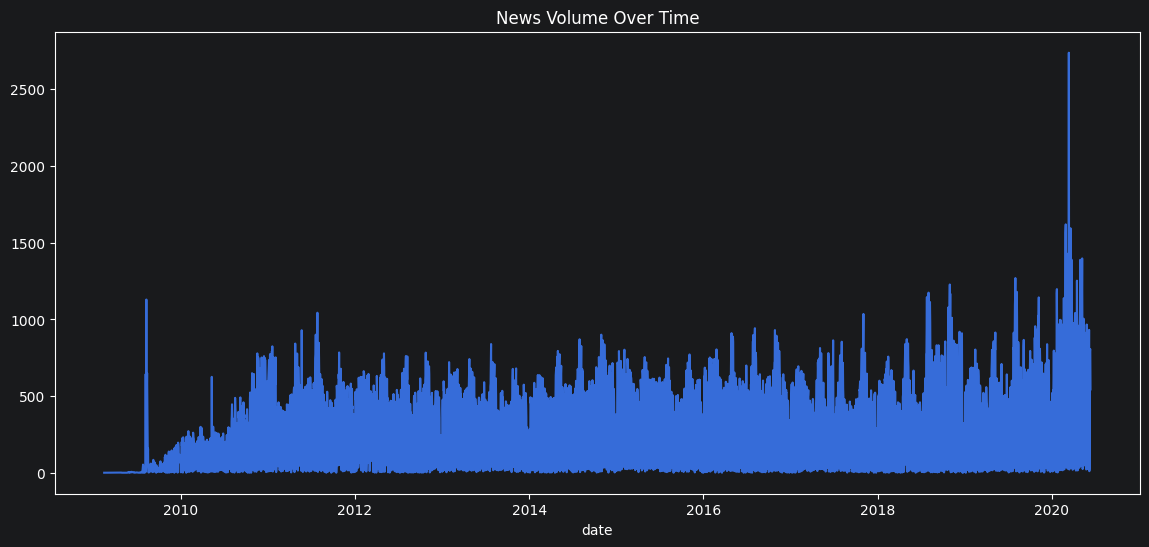

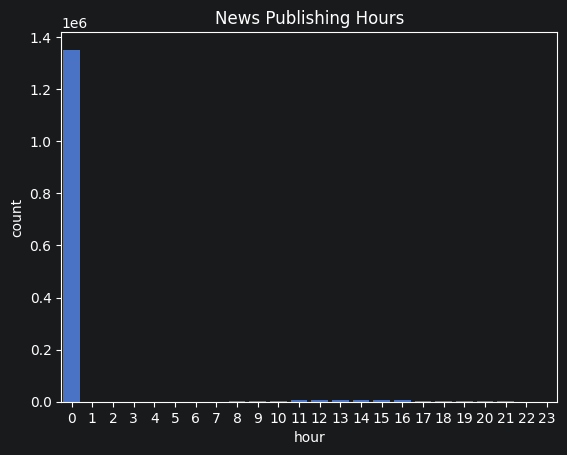

['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


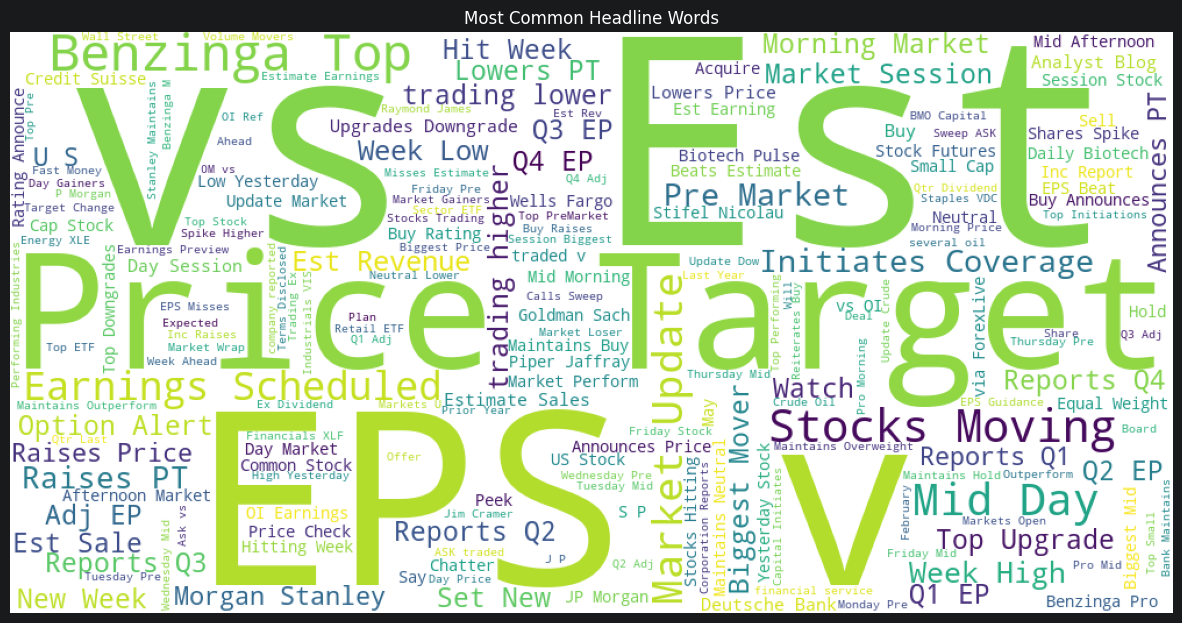

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
#load test
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
df.head()
#basic data set inspection
df.shape
df.info()
df.isnull().sum()
#Descriptive Statistic, headlien length
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

#visualization
plt.figure(figsize=(10,6))
sns.histplot(df['headline_length'], bins=30)
plt.title("Headline Length Distribution")
plt.show()
#publisher analysis
publisher_counts = df['publisher'].value_counts().head(20)

plt.figure(figsize=(12,6))
publisher_counts.plot(kind='bar')
plt.title("Top Publishers")
plt.show()
#pubisher day count
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    errors='coerce',
    utc=True
)
#Then continue normally
daily_news = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(14,6))
daily_news.plot()

plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

#pyton houre analysis
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(12,6))

sns.countplot(x='hour', data=df)

plt.title("Publishing Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Article Count")

plt.show()
plt.figure(figsize=(14,6))
daily_news.plot()
plt.title("News Volume Over Time")
plt.show()
#publisher hour analysis
df['hour'] = df['date'].dt.hour

sns.countplot(x='hour', data=df)
plt.title("News Publishing Hours")
plt.show()
#nlp key word analysis
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X = tfidf.fit_transform(df['headline'].astype(str))

keywords = tfidf.get_feature_names_out()

print(keywords)
#wordcloud
text = " ".join(df['headline'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Common Headline Words")
plt.show()
#extract publisher domain
df['domain'] = df['publisher'].str.extract(r'@(.+)')

df['domain'].value_counts().head(10)

